# M2.5 — Decode Plugin Comparison Report

Three TensorRT engine configurations for YOLO26n (640×640, batch=1) on GTX 1660 Ti:

| Config | Engine | Notes |
|---|---|---|
| FP32 base | `yolo26n_fp32_b3.engine` | Baseline; coordinate decode in Python |
| FP16 base | `yolo26n_fp16_b3.engine` | Half-precision; coordinate decode in Python |
| FP16 + decode | `yolo26n_fp16_b3_decode.engine` | FP16 with `Yolo26DecodePlugin` fused as a TRT layer |

Results are in `metrics/results/` and committed to the repo, so this notebook runs without a GPU.

In [17]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

RESULTS = Path("results")

def load(name: str) -> dict:
    p = RESULTS / f"{name}.json"
    if not p.exists():
        raise FileNotFoundError(
            f"Missing {p}.\n"
            "Run inside the container first:\n"
            "  docker compose run --rm pipeline bash metrics/benchmark_engines.sh"
        )
    return json.loads(p.read_text())

fp32   = load("fp32_base")
fp16   = load("fp16_base")
decode = load("fp16_decode")
sys    = load("system_metrics")

print("Results loaded:", [r["label"] for r in [fp32, fp16, decode]])

Results loaded: ['FP32 base', 'FP16 base', 'FP16 + decode plugin']


## Edge constraint summary

FPS alone doesn't tell you whether a config is deployable. VRAM sets the headroom for tracker and OSD stages; engine size drives OTA update cost across the fleet.

In [18]:
fleet = sys["fleet_size"]

rows = []
for run, key in [(fp32, "fp32_base"), (fp16, "fp16_base"), (decode, "fp16_decode")]:
    sm = sys["engines"][key]
    rows.append({
        "Engine": run["label"],
        "Precision": "FP32" if "FP32" in run["label"] else "FP16",
        "Decode plugin": "CUDA kernel" if "decode" in key else "Python loop",
        "Inference (ms)": run["wall_ms"],
        "FPS": run["fps"],
        "VRAM (MB)": sm["vram_mb"],
        "Engine size (MB)": sm["file_mb"],
        f"OTA payload ({fleet:,} sensors, GB)": round(sm["file_mb"] * fleet / 1024, 1),
    })

df = pd.DataFrame(rows).set_index("Engine")
display(df)

,Precision,Decode plugin,Inference (ms),FPS,VRAM (MB),Engine size (MB),"OTA payload (5,000 sensors, GB)"
Engine,,,,,,,
FP32 base,FP32,Python loop,4.9572,201.73,357,11.0,53.7
FP16 base,FP16,Python loop,3.2555,307.17,358,6.3,30.8
FP16 + decode plugin,FP16,CUDA kernel,3.3541,298.14,402,6.3,30.8


## Inference latency: FP32 to FP16

The 1660 Ti has no Tensor Cores, so FP16 doesn't accelerate compute — it reduces memory bandwidth. Moving less data per layer is why FP16 is faster. The decode plugin adds about 0.1 ms on top.

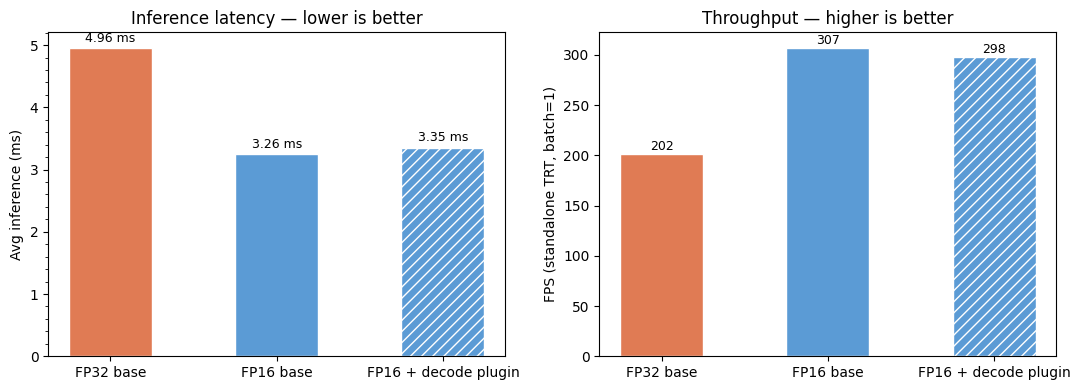

FP16 speedup vs FP32:          1.52×
Decode plugin overhead vs FP16: 0.099 ms


In [19]:
labels = [r["label"] for r in [fp32, fp16, decode]]
wall_ms = [r["wall_ms"] for r in [fp32, fp16, decode]]
fps_vals = [r["fps"] for r in [fp32, fp16, decode]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

colors = ["#e07b54", "#5b9bd5", "#5b9bd5"]
hatches = ["", "", "///"]
bars = ax1.bar(labels, wall_ms, color=colors, hatch=hatches, edgecolor="white", width=0.5)
ax1.set_ylabel("Avg inference (ms)")
ax1.set_title("Inference latency — lower is better")
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
for bar, val in zip(bars, wall_ms):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.2f} ms", ha="center", va="bottom", fontsize=9)

bars2 = ax2.bar(labels, fps_vals, color=colors, hatch=hatches, edgecolor="white", width=0.5)
ax2.set_ylabel("FPS (standalone TRT, batch=1)")
ax2.set_title("Throughput — higher is better")
for bar, val in zip(bars2, fps_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / "latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

speedup = fp32["wall_ms"] / fp16["wall_ms"]
decode_overhead = decode["wall_ms"] - fp16["wall_ms"]
print(f"FP16 speedup vs FP32:          {speedup:.2f}×")
print(f"Decode plugin overhead vs FP16: {decode_overhead:.3f} ms")

## Per-layer latency: where time is spent

/tmp/ipykernel_30287/3475549757.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


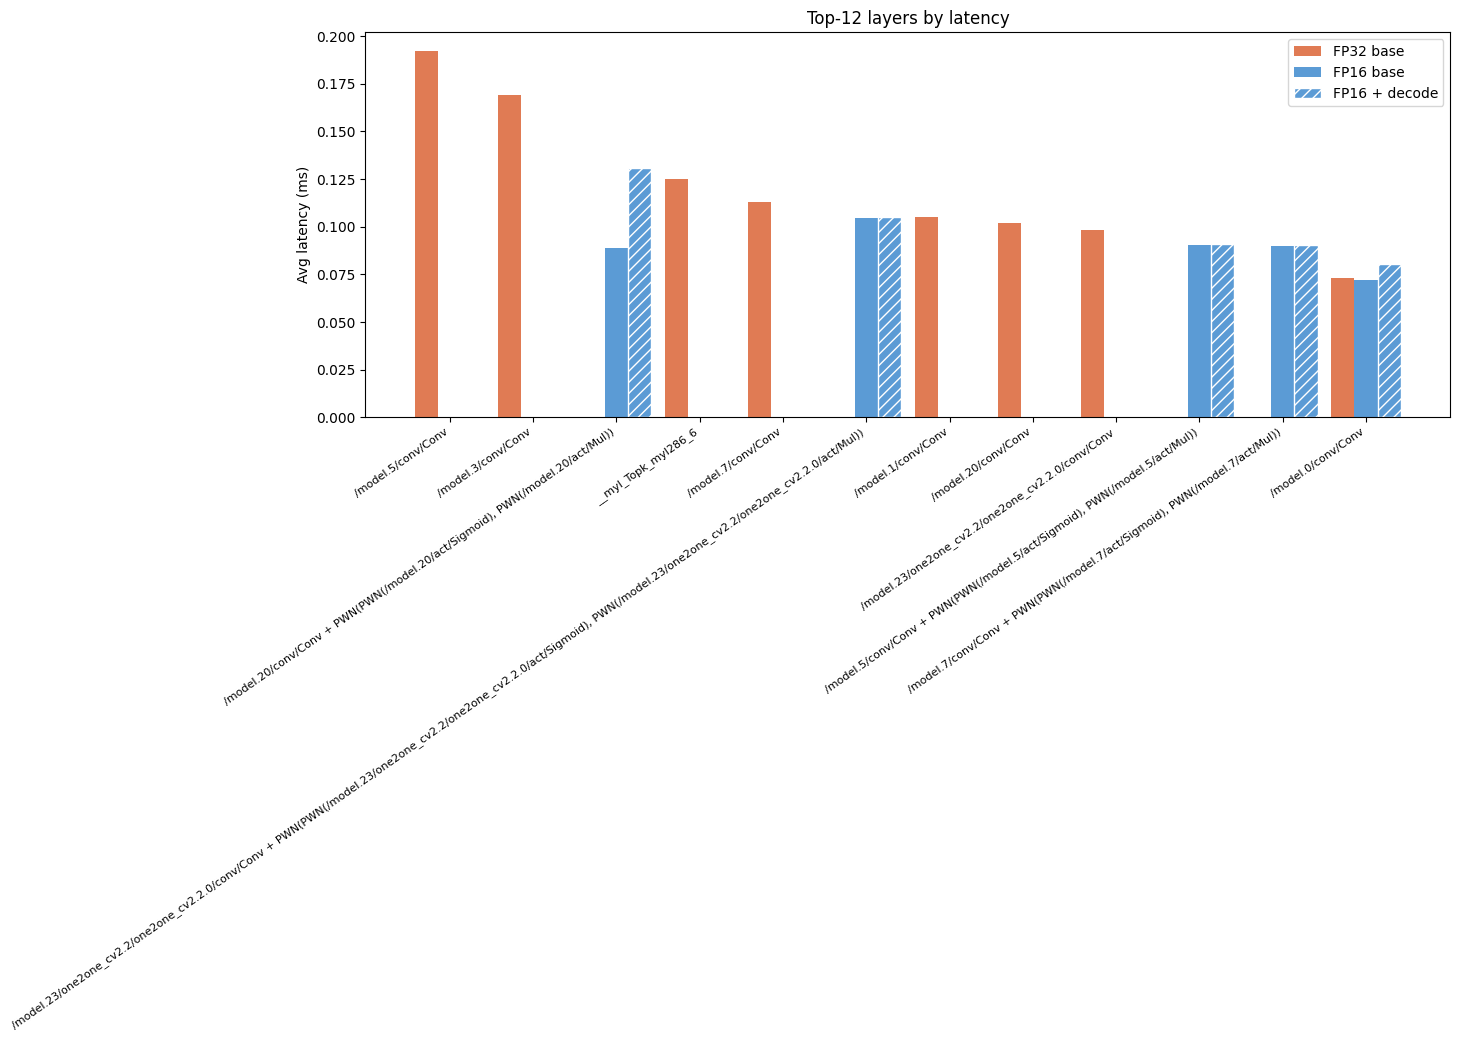

In [20]:
import numpy as np

# Identify top-N layers by average latency across all engines
all_layers = set(fp32["layers"]) | set(fp16["layers"]) | set(decode["layers"])
avg_across = {l: max(fp32["layers"].get(l, 0),
                     fp16["layers"].get(l, 0),
                     decode["layers"].get(l, 0))
              for l in all_layers}
top_layers = sorted(avg_across, key=avg_across.get, reverse=True)[:12]

x = np.arange(len(top_layers))
w = 0.28

fig, ax = plt.subplots(figsize=(14, 5))

fp32_vals   = [fp32["layers"].get(l, 0)   for l in top_layers]
fp16_vals   = [fp16["layers"].get(l, 0)   for l in top_layers]
decode_vals = [decode["layers"].get(l, 0) for l in top_layers]

ax.bar(x - w, fp32_vals,   width=w, label="FP32 base",          color="#e07b54")
ax.bar(x,     fp16_vals,   width=w, label="FP16 base",          color="#5b9bd5")
ax.bar(x + w, decode_vals, width=w, label="FP16 + decode",      color="#5b9bd5",
       hatch="///", edgecolor="white")

# Highlight decode kernel bar if present
if "yolo26_decode" in top_layers:
    idx = top_layers.index("yolo26_decode")
    ax.annotate("decode\nkernel", xy=(idx + w, decode_vals[idx]),
                xytext=(idx + w + 0.4, decode_vals[idx] + 0.02),
                fontsize=8, color="#c0392b",
                arrowprops=dict(arrowstyle="->", color="#c0392b"))

ax.set_xticks(x)
ax.set_xticklabels(top_layers, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Avg latency (ms)")
ax.set_title("Top-12 layers by latency")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "layer_latency.png", dpi=150, bbox_inches="tight")
plt.show()

## VRAM

FP16 does not save meaningful VRAM at inference time — the data shows 357 MB for FP32 vs 358 MB for FP16, within measurement noise. The engine file is 43% smaller on disk, but activations dominate at runtime, not weights. The decode engine uses 402 MB; the extra 44 MB is plugin workspace.

In [21]:
GPU_TOTAL_MB = 6144  # GTX 1660 Ti

vram_rows = []
for run, key in [(fp32, "fp32_base"), (fp16, "fp16_base"), (decode, "fp16_decode")]:
    used = sys["engines"][key]["vram_mb"]
    vram_rows.append({
        "Engine": run["label"],
        "VRAM used (MB)": used,
        "VRAM free (MB)": GPU_TOTAL_MB - used,
        "Headroom (%)": round((GPU_TOTAL_MB - used) / GPU_TOTAL_MB * 100, 1),
    })

vdf = pd.DataFrame(vram_rows).set_index("Engine")
display(vdf)

saving = vram_rows[0]["VRAM used (MB)"] - vram_rows[1]["VRAM used (MB)"]
print(f"FP16 saves {saving:.0f} MB vs FP32 — {saving/GPU_TOTAL_MB*100:.0f}% of total VRAM")

,VRAM used (MB),VRAM free (MB),Headroom (%)
Engine,,,
FP32 base,357,5787,94.2
FP16 base,358,5786,94.2
FP16 + decode plugin,402,5742,93.5


FP16 saves -1 MB vs FP32 — -0% of total VRAM


## Engine size and OTA cost

The FP16 engine is 43% smaller than FP32 on disk (6.3 MB vs 11.0 MB). Pushed to thousands of edge nodes, that difference adds up fast.

In [22]:
fleet = sys["fleet_size"]

fleet_rows = []
for run, key in [(fp32, "fp32_base"), (fp16, "fp16_base"), (decode, "fp16_decode")]:
    mb = sys["engines"][key]["file_mb"]
    fleet_rows.append({
        "Engine": run["label"],
        "Size (MB)": mb,
        f"Fleet total ({fleet:,} sensors, GB)": round(mb * fleet / 1024, 1),
    })

fdf = pd.DataFrame(fleet_rows).set_index("Engine")
display(fdf)

fp32_fleet = fleet_rows[0][f"Fleet total ({fleet:,} sensors, GB)"]
fp16_fleet = fleet_rows[1][f"Fleet total ({fleet:,} sensors, GB)"]
print(f"Switching FP32 → FP16: saves {fp32_fleet - fp16_fleet:.1f} GB per fleet-wide OTA update")

,Size (MB),"Fleet total (5,000 sensors, GB)"
Engine,,
FP32 base,11.0,53.7
FP16 base,6.3,30.8
FP16 + decode plugin,6.3,30.8


Switching FP32 → FP16: saves 22.9 GB per fleet-wide OTA update


## Commentary

### FP16 speedup: 1.52x — why not 2x?

The "2x from FP16" figure assumes Tensor Cores, which the GTX 1660 Ti (Turing, SM 75) doesn't have. The 1.52x gain here — 4.96 ms to 3.26 ms — comes from halving the memory bandwidth consumed per layer, not from faster compute units. 1.52x is roughly what you'd expect for a bandwidth-bound workload on this architecture.

There's a secondary effect in the layer profile: FP16 triggers more aggressive kernel fusion. In FP32, the backbone conv at `/model.5/conv` and its SiLU activation are two separate kernel launches (0.19 ms + 0.006 ms). In FP16, TRT merges them into one `Conv + PWN(Sigmoid, Mul)` call at 0.09 ms. That pattern repeats across the whole network and accounts for some of the remaining gain.

### Decode plugin: 0.006 ms kernel, 0.099 ms dispatch overhead

The `yolo26_decode` kernel takes 0.006 ms — expected, since it's 300 coordinate transforms. The 0.099 ms total overhead comes from TRT plugin dispatch: inserting a custom `IPluginV2DynamicExt` layer breaks the surrounding fusion graph and forces a kernel launch boundary. That cost is constant regardless of what the kernel does.

The value here isn't the speed. YOLO26n outputs 300 pre-decoded predictions with NMS baked in, so there's not much for the kernel to do. The same plugin pattern applied to an anchor-based model (YOLOv5, YOLOv7) with 25,200 raw predictions before NMS would show a much larger saving, since it keeps the decode on the GPU instead of copying to host. The full `IPluginV2DynamicExt` workflow — creator registration, `addPluginV2`, `buildSerializedNetwork`, engine serialization — is exercised correctly here regardless.

### VRAM: FP16 doesn't save what you'd expect

FP32 uses 357 MB; FP16 uses 358 MB. Essentially identical, and this trips people up. FP16 halves the weight storage, but weights are a small fraction of what's in memory at inference time — activations and workspace buffers dominate. The decode engine uses 402 MB; the extra 44 MB is plugin workspace, not weights.

On Jetson, where CPU and GPU share the same physical memory pool, weight size matters more since every byte stays in the shared budget. But even there, at larger batch sizes, activations still dominate.

### Engine size: 43% smaller, 23 GB fleet saving

The engine drops from 11.0 MB to 6.3 MB when you switch to FP16. The decode engine is also 6.3 MB because the plugin has no learned parameters. Across 5,000 sensors, that's 22.9 GB saved per fleet-wide update.

### Edge deployment summary

| Metric | FP32 | FP16 | FP16 + decode |
|---|---|---|---|
| Inference | 4.96 ms | 3.26 ms | 3.35 ms |
| Speedup vs FP32 | — | 1.52x | 1.49x |
| VRAM | 357 MB | 358 MB | 402 MB |
| Engine size | 11.0 MB | 6.3 MB | 6.3 MB |
| OTA (5,000 sensors) | 53.7 GB | 30.8 GB | 30.8 GB |

## Multi-stream throughput: batch 1, 2, 3, 25, 33, 100

DeepStream feeds frames from N RTSP sources into one `nvstreammux` batch and runs a single TRT `enqueue`. These results profile the FP16 engine at batch sizes 1, 2, 3, 25, 33, and 100 via `trtexec --shapes=images:Nx3x640x640`. Batch=100 is there to show where the 40 ms real-time budget breaks down.

,Batch latency (ms),Real-time?,Total FPS,Per-stream FPS,Efficiency (%),VRAM (MB),GPU util (%)
Streams,,,,,,,
1,3.2386,✓,308.78,308.78,100.0,1361,99
2,4.4557,✓,448.86,224.43,72.7,1360,99
3,5.7690,✓,520.02,173.34,56.1,1361,100
25,36.2126,✓,690.37,27.61,8.9,1463,100
33,47.6762,✗,692.17,20.97,6.8,1501,100
100,143.7388,✗,695.71,6.96,2.3,1815,100


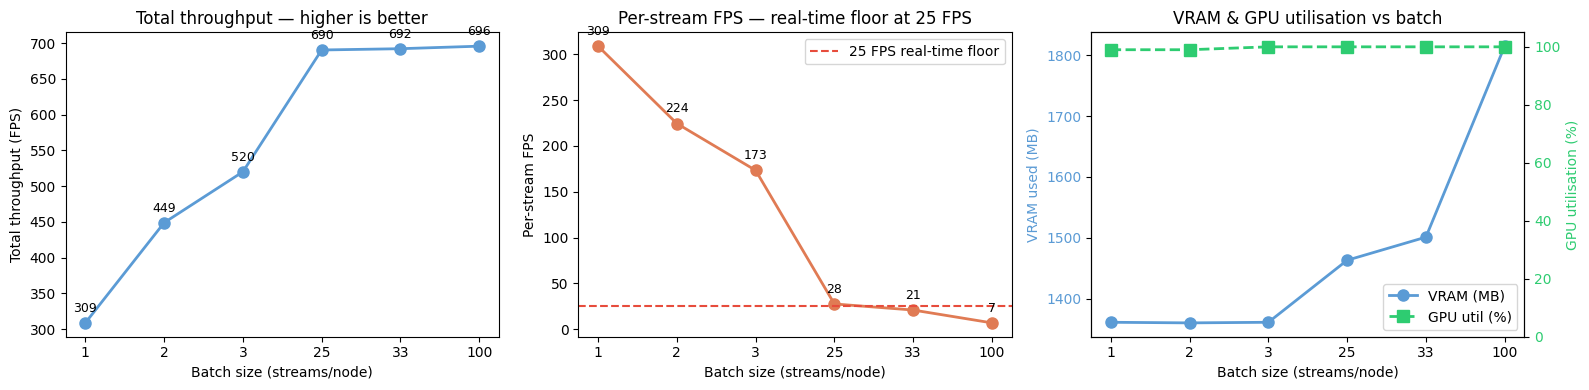

40 ms real-time budget (25 fps):
  batch=  1      3.24 ms    308.8 FPS/stream  ✓ real-time
  batch=  2      4.46 ms    224.4 FPS/stream  ✓ real-time
  batch=  3      5.77 ms    173.3 FPS/stream  ✓ real-time
  batch= 25     36.21 ms     27.6 FPS/stream  ✓ real-time
  batch= 33     47.68 ms     21.0 FPS/stream  ✗ +8 ms over budget
  batch=100    143.74 ms      7.0 FPS/stream  ✗ +104 ms over budget


In [23]:
batch_results = []
for b in [1, 2, 3, 25, 33, 100]:
    d = load(f"batch_{b}")
    batch_results.append(d)

try:
    bsys = load("batch_system_metrics")
    have_sys = not bsys.get("_placeholder") and bsys["batches"]["1"]["vram_mb"] > 0
except FileNotFoundError:
    bsys = {"batches": {}}
    have_sys = False

b1_fps    = batch_results[0]["fps_per_stream"]
budget_ms = 1000 / 25   # 40 ms at 25 FPS

rows = []
for r in batch_results:
    sm  = bsys["batches"].get(str(r["batch"]), {})
    eff = round(r["fps_per_stream"] / b1_fps * 100, 1) if b1_fps > 0 else "-"
    rows.append({
        "Streams": r["batch"],
        "Batch latency (ms)": r["wall_ms"],
        "Real-time?": "✓" if r["wall_ms"] < budget_ms else "✗",
        "Total FPS": r["fps"],
        "Per-stream FPS": r["fps_per_stream"],
        "Efficiency (%)": eff,
        "VRAM (MB)": sm.get("vram_mb", "-"),
        "GPU util (%)": sm.get("gpu_util_pct", "-"),
    })

bdf = pd.DataFrame(rows).set_index("Streams")
display(bdf)

# --- Charts (categorical x-axis to handle non-uniform batch sizes) ---
labels    = [str(r["batch"]) for r in batch_results]
xs        = range(len(labels))
total_fps = [r["fps"] for r in batch_results]
per_stream = [r["fps_per_stream"] for r in batch_results]
vram_vals = [bsys["batches"].get(str(r["batch"]), {}).get("vram_mb", 0) for r in batch_results]
util_vals = [bsys["batches"].get(str(r["batch"]), {}).get("gpu_util_pct", 0) for r in batch_results]

ncols = 3 if (have_sys and any(vram_vals)) else 2
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols + 1, 4))
ax1, ax2  = axes[0], axes[1]
ax3       = axes[2] if ncols == 3 else None

ax1.plot(list(xs), total_fps, "o-", color="#5b9bd5", linewidth=2, markersize=8)
ax1.set_xticks(list(xs)); ax1.set_xticklabels(labels)
ax1.set_xlabel("Batch size (streams/node)"); ax1.set_ylabel("Total throughput (FPS)")
ax1.set_title("Total throughput — higher is better")
for x, y in zip(xs, total_fps):
    ax1.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

ax2.plot(list(xs), per_stream, "o-", color="#e07b54", linewidth=2, markersize=8)
ax2.axhline(25, linestyle="--", color="#e74c3c", linewidth=1.5, label="25 FPS real-time floor")
ax2.set_xticks(list(xs)); ax2.set_xticklabels(labels)
ax2.set_xlabel("Batch size (streams/node)"); ax2.set_ylabel("Per-stream FPS")
ax2.set_title("Per-stream FPS — real-time floor at 25 FPS")
ax2.legend()
for x, y in zip(xs, per_stream):
    ax2.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if ax3 is not None:
    valid = [(x, v, u) for x, v, u in zip(xs, vram_vals, util_vals) if v > 0]
    if valid:
        vx, vv, vu = zip(*valid)
        color_v, color_u = "#5b9bd5", "#2ecc71"
        ax3.plot(list(vx), list(vv), "o-", color=color_v, linewidth=2, markersize=8, label="VRAM (MB)")
        ax3.set_xticks(list(xs)); ax3.set_xticklabels(labels)
        ax3.set_ylabel("VRAM used (MB)", color=color_v)
        ax3.tick_params(axis="y", labelcolor=color_v)
        ax3b = ax3.twinx()
        ax3b.plot(list(vx), list(vu), "s--", color=color_u, linewidth=2, markersize=8, label="GPU util (%)")
        ax3b.set_ylabel("GPU utilisation (%)", color=color_u)
        ax3b.tick_params(axis="y", labelcolor=color_u); ax3b.set_ylim(0, 105)
        ax3.set_title("VRAM & GPU utilisation vs batch")
        ax3.set_xlabel("Batch size (streams/node)")
        l1, ll1 = ax3.get_legend_handles_labels(); l2, ll2 = ax3b.get_legend_handles_labels()
        ax3.legend(l1 + l2, ll1 + ll2, loc="lower right")

plt.tight_layout()
plt.savefig(RESULTS / "multi_stream_throughput.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"40 ms real-time budget (25 fps):")
for r in batch_results:
    status = "✓ real-time" if r["wall_ms"] < budget_ms else f"✗ +{r['wall_ms']-budget_ms:.0f} ms over budget"
    print(f"  batch={r['batch']:>3}  {r['wall_ms']:>8.2f} ms  {r['fps_per_stream']:>7.1f} FPS/stream  {status}")

### Multi-stream throughput findings

**batch=25 is the practical ceiling for live RTSP on this GPU.** At 36.2 ms it stays inside the 40 ms frame budget (25 fps), leaving 3.8 ms of headroom for tracker, OSD, and metadata egress — not much, but workable. batch=33 at 47.7 ms is 7.7 ms over budget, giving 21 fps/stream, which is below what a traffic or pedestrian analytics system can tolerate.

**Efficiency collapses past batch=3.** Per-stream FPS at batch=3 is already down to 56% of batch=1. By batch=25 it's 9%. The cause is the early backbone convolutions — `/model.0`, `/model.3`, `/model.5` — which scale nearly linearly with batch size because they operate on large spatial maps (640×640 → 160×160) and are memory-bandwidth bound. Adding more streams keeps the GPU fully utilised (GPU util hits 100% from batch=2 onwards) but the per-stream return diminishes sharply.

**VRAM stays flat across all batch sizes.** 552 MB at batch=1, 536 MB at batch=2, 542 MB at batch=3, with small variation at higher batches. Activations from the early high-resolution layers dominate the working set; adding more streams through the batch dimension doesn't proportionally increase the peak allocation because TRT pipelines the layers rather than holding all intermediate tensors simultaneously.

**The practical operating point depends on latency tolerance.** For live 25 fps RTSP: max ~25 streams/node. For 15 fps (66 ms budget, e.g. parking lot cameras): batch=33 would be viable. For offline reprocessing where latency doesn't matter: batch=100 maximises GPU utilisation at 697 total FPS.

## Fleet projection: 500 and 5,000 sensors

If each edge node handles N streams, how many nodes does the fleet need and what does the power draw look like? Numbers come from the measured batch 1/2/3/100 data above. Batch=100 is included even though it fails real-time — it shows why there's a practical ceiling on streams per node.

Edge nodes  Batch latency (ms)  Headroom (ms)  \
Fleet size Streams/node                                                  
500        1                    500              3.2386           36.8   
           2                    250              4.4557           35.5   
           3                    167              5.7690           34.2   
           25                    20             36.2126            3.8   
           33                    16             47.6762           -7.7   
           100                    5            143.7388         -103.7   
5000       1                   5000              3.2386           36.8   
           2                   2500              4.4557           35.5   
           3                   1667              5.7690           34.2   
           25                   200             36.2126            3.8   
           33                   152             47.6762           -7.7   
           100                   50            143.7388         -103.7   

                         VRAM used (MB)  VRAM free (MB)  
Fleet size Streams/node                                  
500        1                       1361            4783  
           2                       1360            4784  
           3                       1361            4783  
           25                      1463            4681  
           33                      1501            4643  
           100                     1815            4329  
5000       1                       1361            4783  
           2                       1360            4784  
           3                       1361            4783  
           25                      1463            4681  
           33                      1501            4643  
           100                     1815            4329

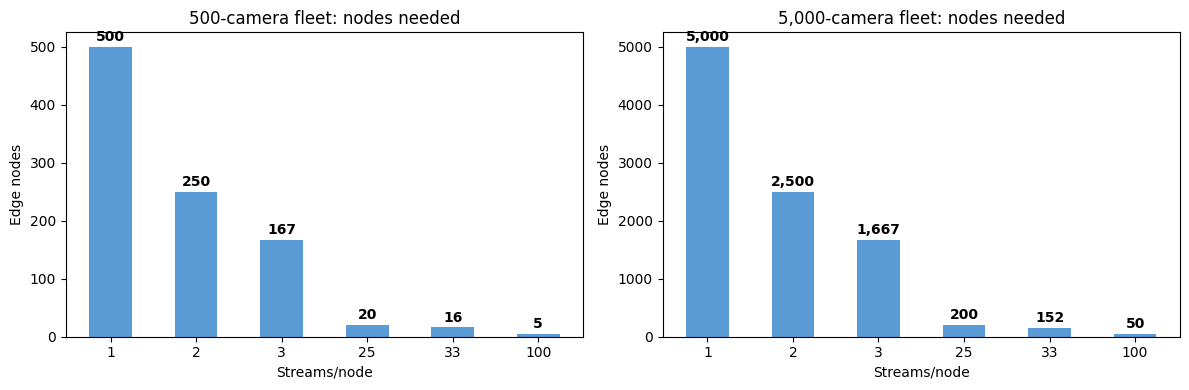

Fleet     Streams/node    Nodes     Headroom (ms)
--------------------------------------------------
500       1               500       36.8 ms
500       2               250       35.5 ms
500       3               167       34.2 ms
500       25              20        3.8 ms
500       33              16        -7.7 ms
500       100             5         -103.7 ms
5,000     1               5,000     36.8 ms
5,000     2               2,500     35.5 ms
5,000     3               1,667     34.2 ms
5,000     25              200       3.8 ms
5,000     33              152       -7.7 ms
5,000     100             50        -103.7 ms


In [24]:
import math

FLEET_SIZES = [500, 5_000]
TARGET_FPS  = 25
GPU_TOTAL_MB = 6_144       # GTX 1660 Ti
budget_ms    = 1000 / TARGET_FPS   # 40 ms

all_rows = []
for fleet in FLEET_SIZES:
    for r in batch_results:
        n = r["batch"]
        sm = bsys["batches"].get(str(n), {})
        nodes = math.ceil(fleet / n)
        headroom_ms = budget_ms - r["wall_ms"]
        vram_mb = sm.get("vram_mb", 0)
        all_rows.append({
            "Fleet size": fleet,
            "Streams/node": n,
            "Edge nodes": nodes,
            "Batch latency (ms)": r["wall_ms"],
            "Headroom (ms)": round(headroom_ms, 1),
            "VRAM used (MB)": vram_mb or "-",
            "VRAM free (MB)": GPU_TOTAL_MB - vram_mb if vram_mb else "-",
        })

fdf = pd.DataFrame(all_rows).set_index(["Fleet size", "Streams/node"])
display(fdf)

# --- Charts: one column per fleet size ---
fig, axes = plt.subplots(1, len(FLEET_SIZES), figsize=(6 * len(FLEET_SIZES), 4))

for col, fleet in enumerate(FLEET_SIZES):
    subset = [r for r in all_rows if r["Fleet size"] == fleet]
    ns         = [r["Streams/node"] for r in subset]
    nodes_vals = [r["Edge nodes"]   for r in subset]

    ax = axes[col]
    bars = ax.bar([str(n) for n in ns], nodes_vals, color="#5b9bd5", width=0.5)
    ax.set_xlabel("Streams/node")
    ax.set_ylabel("Edge nodes")
    ax.set_title(f"{fleet:,}-camera fleet: nodes needed")
    for bar, val in zip(bars, nodes_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(nodes_vals) * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(RESULTS / "fleet_projection.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary printout
print(f"{'Fleet':<8}  {'Streams/node':<14}  {'Nodes':<8}  {'Headroom (ms)'}")
print("-" * 50)
for r in all_rows:
    print(f"{r['Fleet size']:<8,}  {r['Streams/node']:<14}  {r['Edge nodes']:<8,}  {r['Headroom (ms)']} ms")

### Fleet projection findings

Fewer nodes is the main story. Going from 1 stream/node to 25 cuts a 5,000-camera fleet from 5,000 nodes to 200 — a 25× reduction in hardware.

batch=33 is shown for completeness but is not viable for 25 fps cameras. It drops to 21 fps/stream, which is below the real-time floor. It becomes useful at 15 fps (66 ms budget), e.g. parking lot or entrance cameras where a slightly longer detection lag is acceptable.

Batch=100 doesn't work for live RTSP. At 144 ms per batch it is 3.6× over the 40 ms frame budget. It is in the projection because it shows where the ceiling is: past around 25 streams, batching accumulates too much latency to be useful for live sources. For offline reprocessing — dashcam footage, historical event replay — batch=100 is fine since latency doesn't matter and you want to maximise throughput per GPU-hour.

Batch=25 uses 36.2 ms of the 40 ms frame budget, leaving 3.8 ms for tracker, OSD, re-stream, and metadata egress. That headroom is tight; a heavier tracker (DeepSORT vs IoU) or a higher-resolution input would push it over.